# Quantization

Quantization maps a continuous or high-precision range of real values $r \in \mathbb{R}$ into a discrete set of lower-precision representations $q \in \mathbb{Z}$.

## Symmetric Quantization

When weight distributions are centered around zero, the zero-point is constrained to $Z = 0$, simplifying hardware arithmetic. For a signed integer range $[-q_{\text{max}}, q_{\text{max}}]$ (e.g., $[-127, 127]$ for signed $\text{INT8}$):

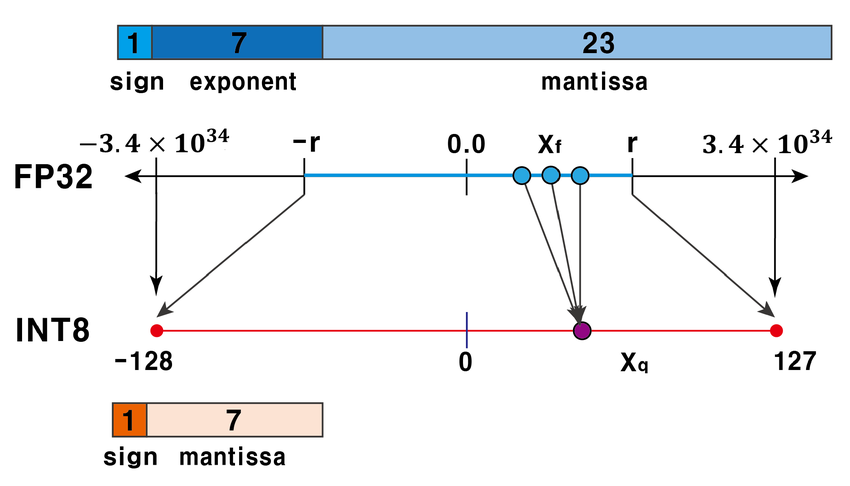

$$S = \frac{\max(\vert{}r_{\text{min}}\vert{}, \vert{}r_{\text{max}}\vert{})}{q_{\text{max}}}$$

$$q = \text{clamp}\left( \left\lfloor \frac{r}{S} \right\rceil, \, -q_{\text{max}}, \, q_{\text{max}} \right)$$

$$\hat{r} = S \cdot q$$

# Asymmetric Quantization

![alt text](image.png)

In Uniform Asymmetric Quantization, real values $r \in [r_{\text{min}}, r_{\text{max}}]$ are mapped to quantized integer bounds $[q_{\text{min}}, q_{\text{max}}]$ (e.g., $[0, 255]$ for unsigned $\text{INT8}$).The quantization equation is given by: $$q = \text{clamp}\left( \left\lfloor \frac{r}{S} \right\rceil + Z, \, q_{\text{min}}, \, q_{\text{max}} \right)$$Where $S \in \mathbb{R}^+$ is the Scale Factor, which determines the step size between quantization bins: $$S = \frac{r_{\text{max}} - r_{\text{min}}}{q_{\text{max}} - q_{\text{min}}}$$ $Z \in \mathbb{Z}$ is the Zero-Point, an integer offset that guarantees real-value zero ($0.0$) maps cleanly to a valid integer:$$Z = \text{round}\left( \frac{-r_{\text{min}}}{S} \right) + q_{\text{min}}$$The Dequantization formula reconstructs the floating-point approximation $\hat{r} \approx r$:$$\hat{r} = S \cdot (q - Z)$$

## Dequantization

# Code Example

### Quantization and Dequantization 

In [ ]:
import numpy as np
np.random.seed(0)


def quantize_symmetric(x, bits=8, axis=None):
    qmax = 2 ** (bits - 1) - 1
    max_abs = np.max(np.abs(x), axis=axis, keepdims=True)
    scale = np.where(max_abs == 0, 1.0, max_abs / qmax)
    q = np.clip(np.round(x / scale), -qmax, qmax).astype(np.int8)  # int8 container 
    return q, scale

def dequantize_symmetric(q, scale):
    return q.astype(np.float32) * scale


def quantize_affine(x, bits=8):
    qmin, qmax = 0, 2 ** bits - 1
    x_min, x_max = x.min(), x.max()
    scale = (x_max - x_min) / (qmax - qmin)
    zero_point = int(np.round(qmin - x_min / scale))
    q = np.clip(np.round(x / scale) + zero_point, qmin, qmax).astype(np.uint8)
    return q, scale, zero_point

def dequantize_affine(q, scale, zero_point):
    return scale * (q.astype(np.float32) - zero_point)

